# Classification Track — Car Features & Vehicle Size Dataset
### 23CSE301 Machine Learning — Capstone Project (Review 1, Part A)

**Objective**: Predict a car's **Vehicle Size** class (`Compact` / `Midsize` / `Large`) — a 3-class
multiclass target — from its specification attributes (engine, transmission, drivetrain, fuel
economy, body style, brand, price), training and comparing five classification algorithms.

**Dataset**: `data.csv` — 11,914 vehicles, 16 columns (Make, Model, Year, Engine specs,
Transmission, Drivetrain, Doors, Market Category, Vehicle Size/Style, MPG, Popularity, MSRP).
This mirrors the "Car Features and MSRP" dataset commonly used for regression on MSRP — here it is
repurposed for classification by using **Vehicle Size** as the target instead.

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="colorblind")
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)


KeyboardInterrupt



<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section A — Dataset And EDA
</h1>
<h2 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
A1. Dataset Loading & Audit
</h2>

In [2]:
df = pd.read_csv('data/cars.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [4]:
print("Shape:", df.shape)

print("\n=== Missing value counts ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=== Target (Vehicle Size) distribution ===")
print(df['Vehicle Size'].value_counts())
print((df['Vehicle Size'].value_counts(normalize=True) * 100).round(1))

print("\n=== Duplicate rows ===")
print(df.duplicated().sum())

Shape: (11914, 16)

=== Missing value counts ===
                  Missing Count  Missing %
Market Category            3742      31.41
Engine HP                    69       0.58
Engine Cylinders             30       0.25
Number of Doors               6       0.05
Engine Fuel Type              3       0.03

=== Target (Vehicle Size) distribution ===
Vehicle Size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64
Vehicle Size
Compact    40.0
Midsize    36.7
Large      23.3
Name: proportion, dtype: float64

=== Duplicate rows ===
715


**Observation (A1 audit):** The dataset has 11,914 rows and 16 columns describing individual
vehicle trims (Make, Model, Year, engine specs, transmission, drivetrain, body style, fuel economy,
popularity and MSRP). Six columns have missing values, the worst being `Market Category` at 31.4%
missing (many mainstream trims simply have no market-category tag) — the rest (`Engine HP`,
`Engine Cylinders`, `Number of Doors`, `Engine Fuel Type`) have well under 1% missing each. There
are also 715 exact duplicate rows (6% of the data), which need to be removed before splitting so the
same car spec doesn't leak into both train and test. The target `Vehicle Size` is a 3-class,
moderately balanced field: Compact 40.0%, Midsize 36.7%, Large 23.3% — balanced enough that plain
`accuracy` is still informative, but weighted Precision/Recall/F1 and stratified splitting are still
used since Large is a clear minority class.

### A2. EDA Visualisations

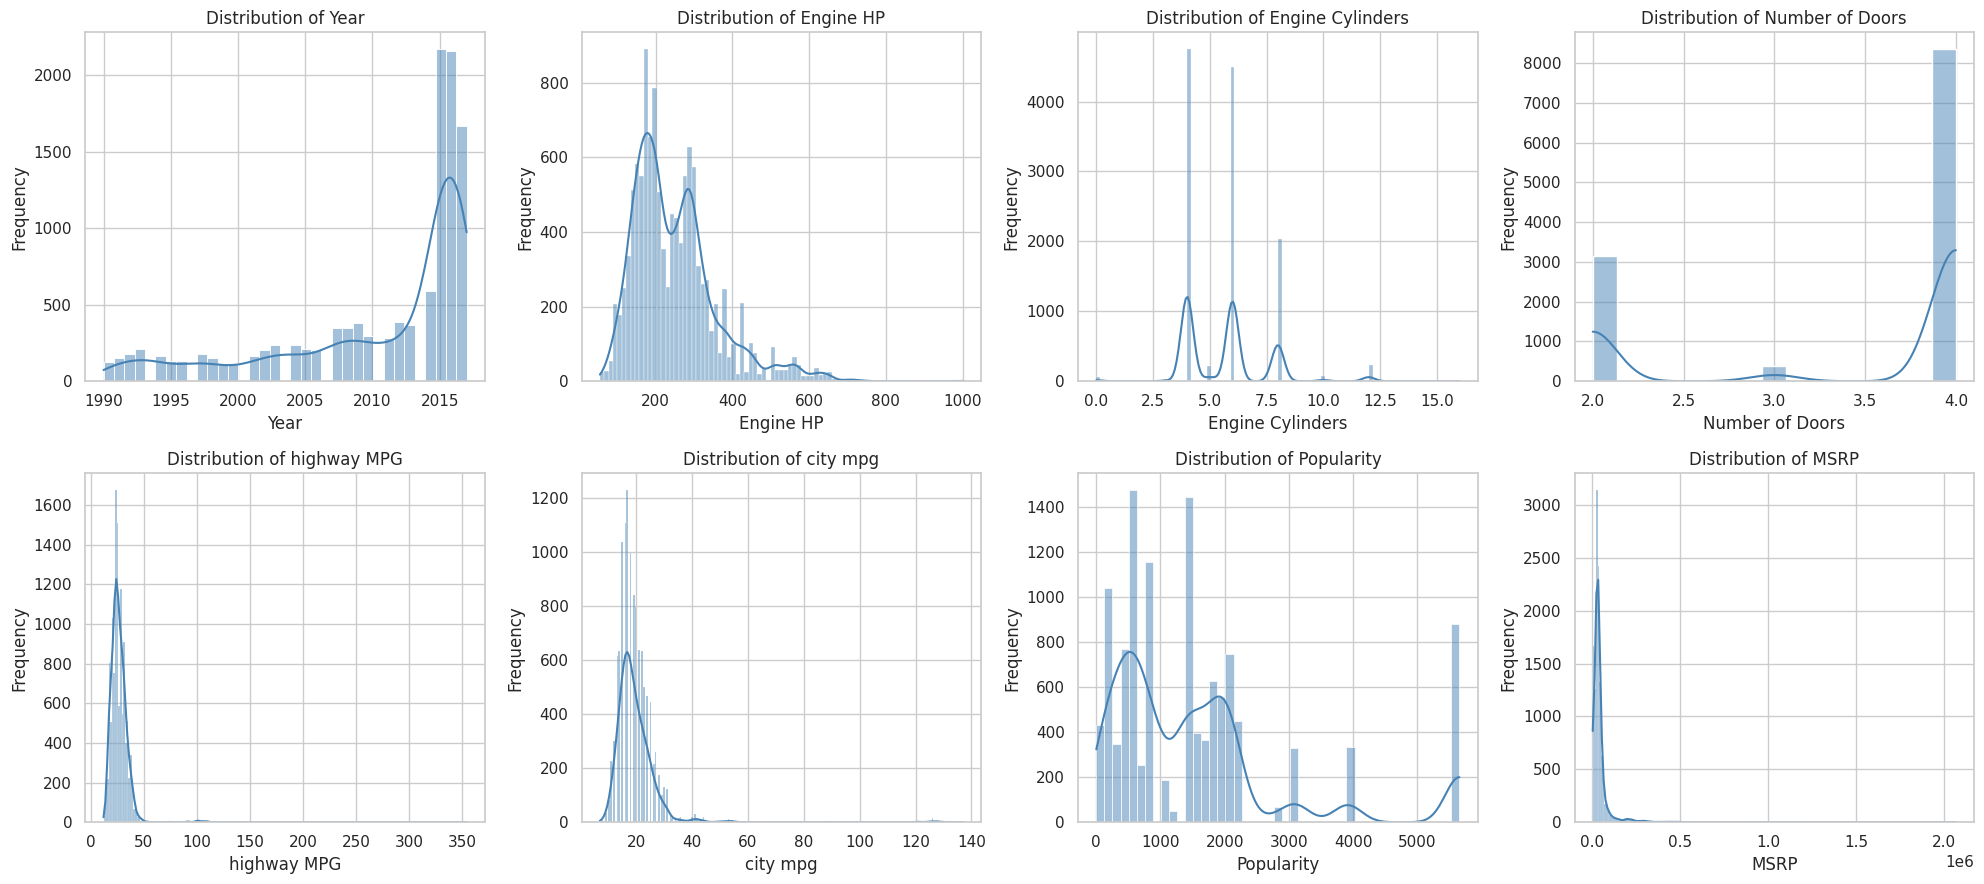

In [5]:
# Distribution plots for numeric features
num_cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
            'highway MPG', 'city mpg', 'Popularity', 'MSRP']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=100)
plt.show()

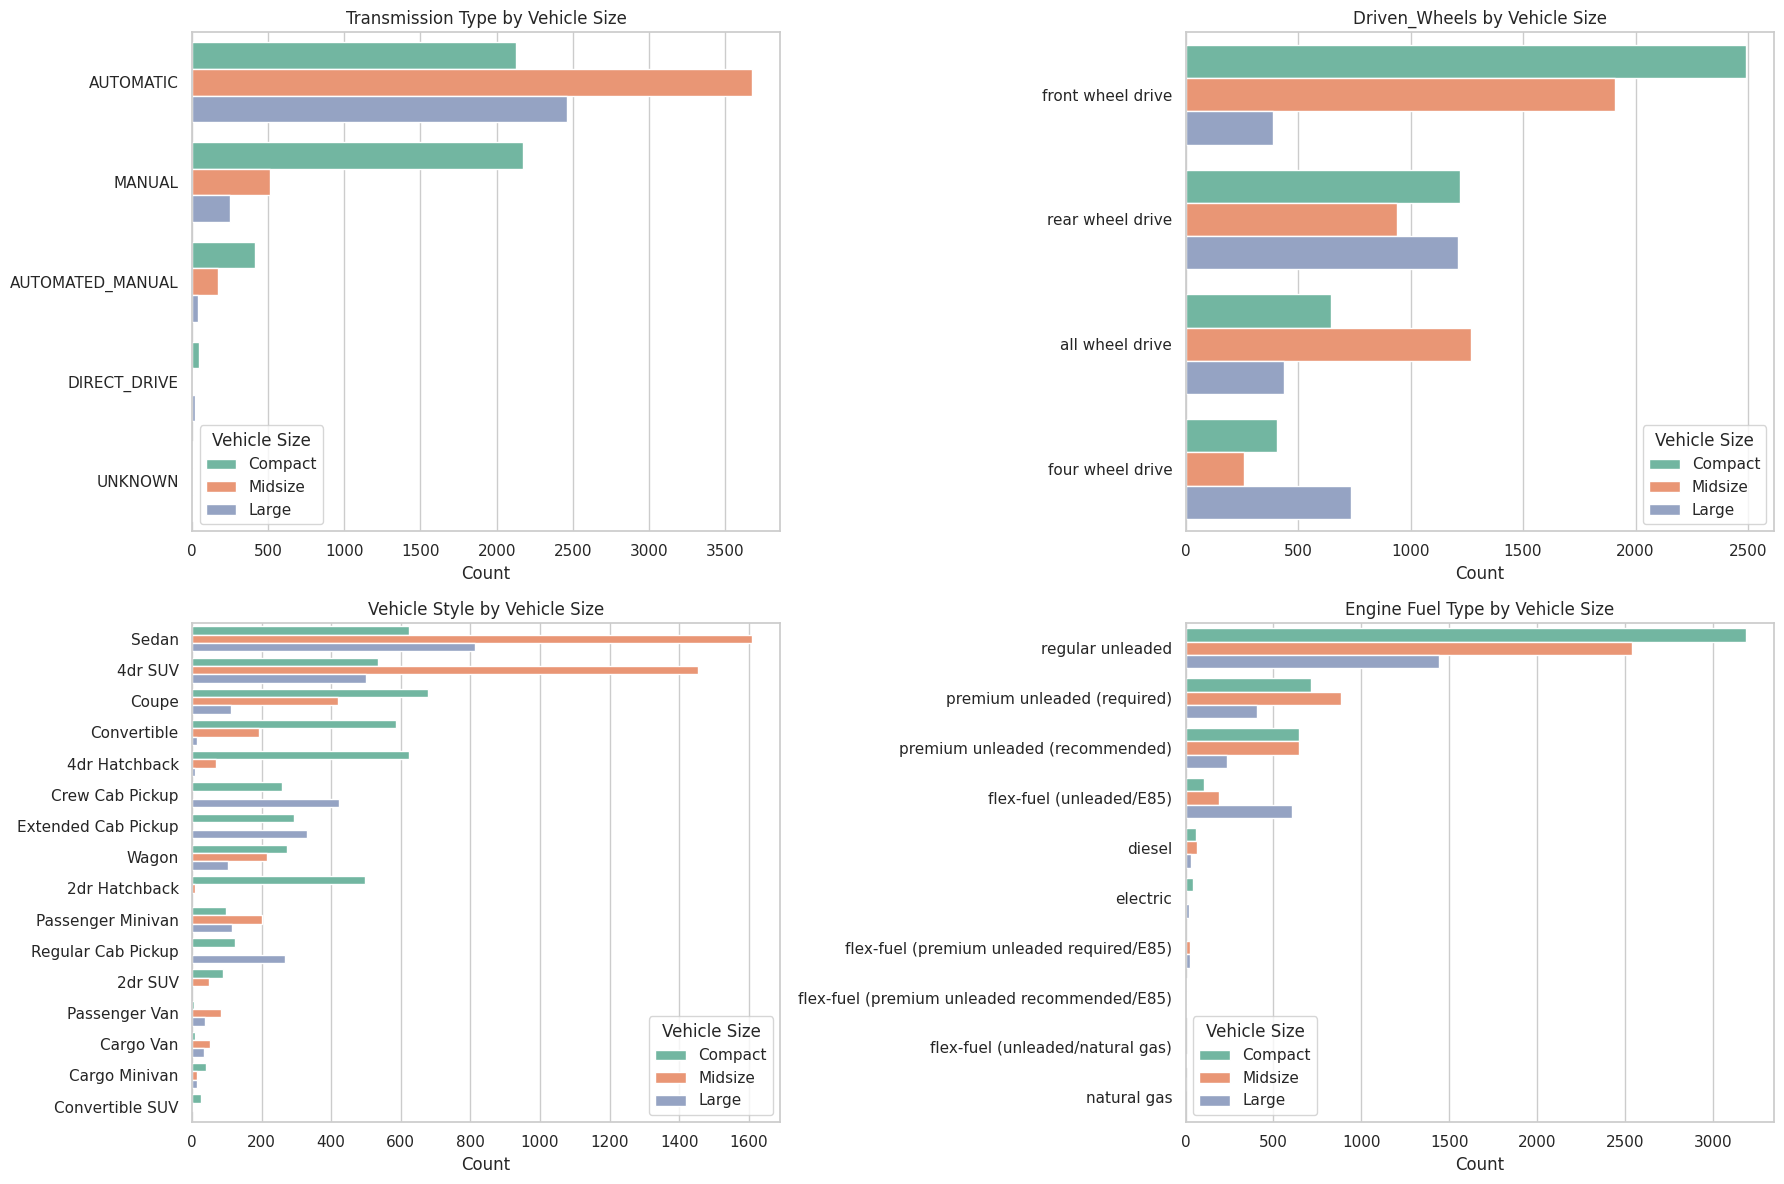

In [6]:
# Distribution of categorical features, split by Vehicle Size
cat_cols = ['Transmission Type', 'Driven_Wheels', 'Vehicle Style', 'Engine Fuel Type']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='Vehicle Size', ax=ax, order=order, palette='Set2')
    ax.set_title(f'{col} by Vehicle Size')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight', dpi=100)
plt.show()

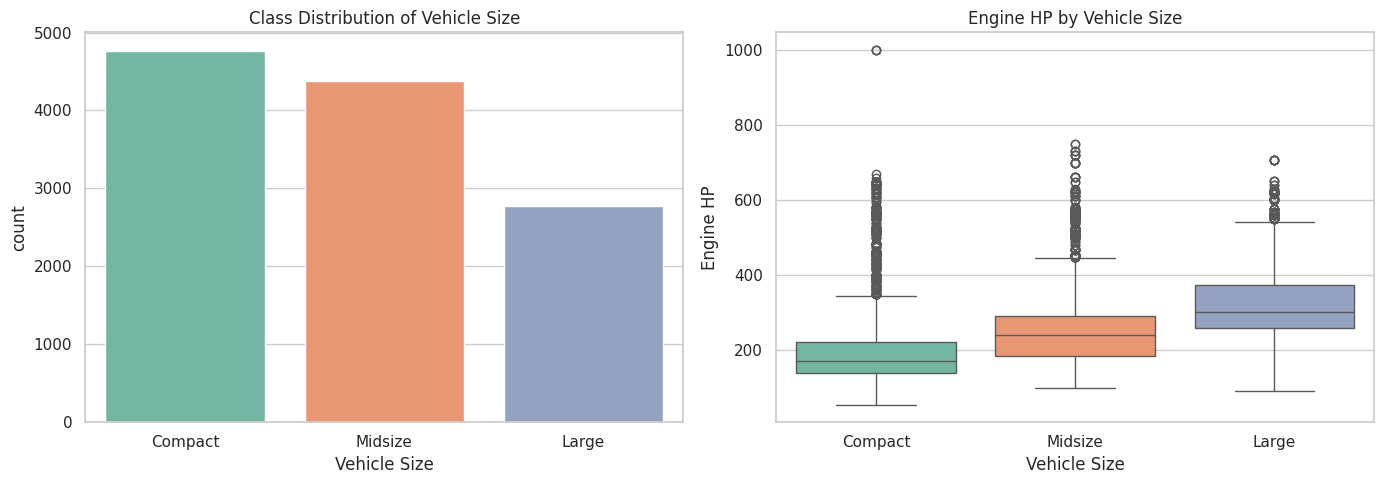

In [7]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Vehicle Size', hue='Vehicle Size', ax=axes[0],
              order=['Compact', 'Midsize', 'Large'], legend=False, palette='Set2')
axes[0].set_title('Class Distribution of Vehicle Size')
axes[0].set_xlabel('Vehicle Size')

sns.boxplot(data=df, x='Vehicle Size', y='Engine HP', ax=axes[1],
            order=['Compact', 'Midsize', 'Large'], hue='Vehicle Size', palette='Set2')
axes[1].set_title('Engine HP by Vehicle Size')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

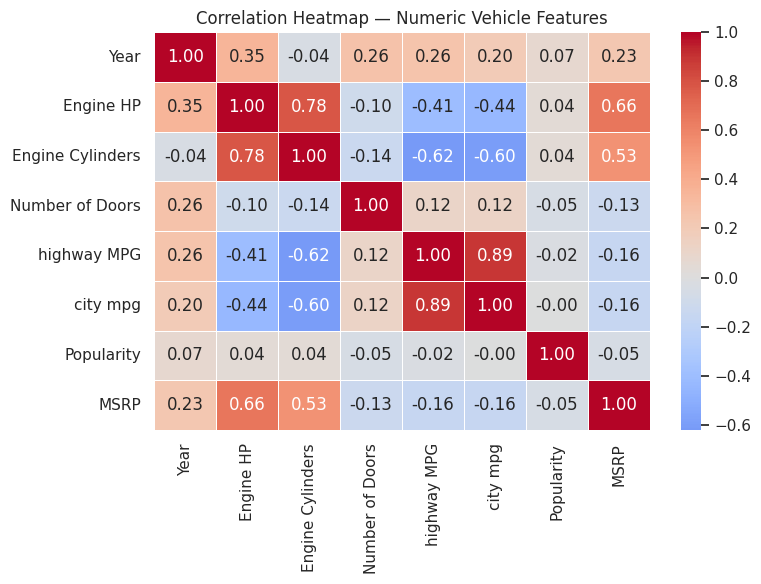

In [8]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df[num_cols].copy()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap — Numeric Vehicle Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

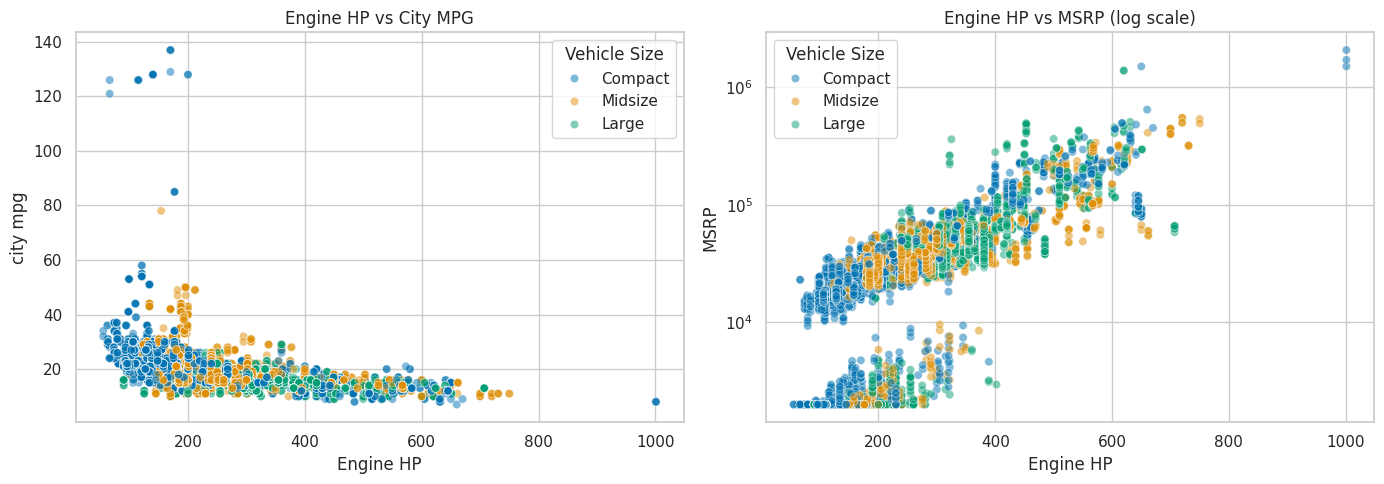

In [9]:
# Scatter plots: feature relationships, coloured by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Engine HP', y='city mpg', hue='Vehicle Size',
                 hue_order=['Compact', 'Midsize', 'Large'], ax=axes[0], alpha=0.5)
axes[0].set_title('Engine HP vs City MPG')

sns.scatterplot(data=df, x='Engine HP', y='MSRP', hue='Vehicle Size',
                 hue_order=['Compact', 'Midsize', 'Large'], ax=axes[1], alpha=0.5)
axes[1].set_yscale('log')
axes[1].set_title('Engine HP vs MSRP (log scale)')

plt.tight_layout()
plt.savefig('scatter_relationships.png', bbox_inches='tight', dpi=100)
plt.show()

### A3. Insight commentary

**Observation:**

- **Target distribution**: `Vehicle Size` is reasonably balanced (40% Compact, 37% Midsize, 23%
  Large) — no aggressive resampling is needed, but Large remains the minority class and stratified
  splitting matters.
- **Engine HP by size**: Large vehicles have a visibly higher median horsepower than Compact ones,
  with Midsize sitting in between — HP alone carries real separating signal for this target.
- **Numeric distributions**: `MSRP` and `Popularity` are both heavily right-skewed (a small number
  of ultra-luxury/exotic trims and a handful of very popular mass-market makes dominate the tail),
  so both benefit from IQR-based outlier capping before modelling. `Engine HP` and `Engine Cylinders`
  are roughly unimodal with a right tail from high-performance trims.
- **Categorical distributions**: `Driven_Wheels` shows a strong pattern — front-wheel-drive cars
  skew heavily Compact, while four/all-wheel-drive skews toward Midsize/Large (trucks and SUVs).
  `Vehicle Style` is almost a direct proxy in places (e.g. "2dr Hatchback" is nearly all Compact,
  "Crew Cab Pickup" is nearly all Large), which is expected since size and body style are correlated
  physical attributes of the same vehicle, not one derived from the other.
- **Engine HP vs City MPG**: a clear inverse relationship — Large vehicles cluster in the
  high-HP/low-MPG region, Compacts cluster in the low-HP/high-MPG region, confirming the fuel-economy
  vs. size trade-off visible in the correlation heatmap (`highway MPG`/`city mpg` are strongly
  negatively correlated with `Engine HP`/`Engine Cylinders`).

<h1 style="font-family: Arial, sans-serif; font-size: 26px; font-weight: 400;">
Extra EDA — Additional Exploratory Analysis
</h1>
<p>Beyond the required plots above, a few more views help build intuition about the dataset before
modelling.</p>

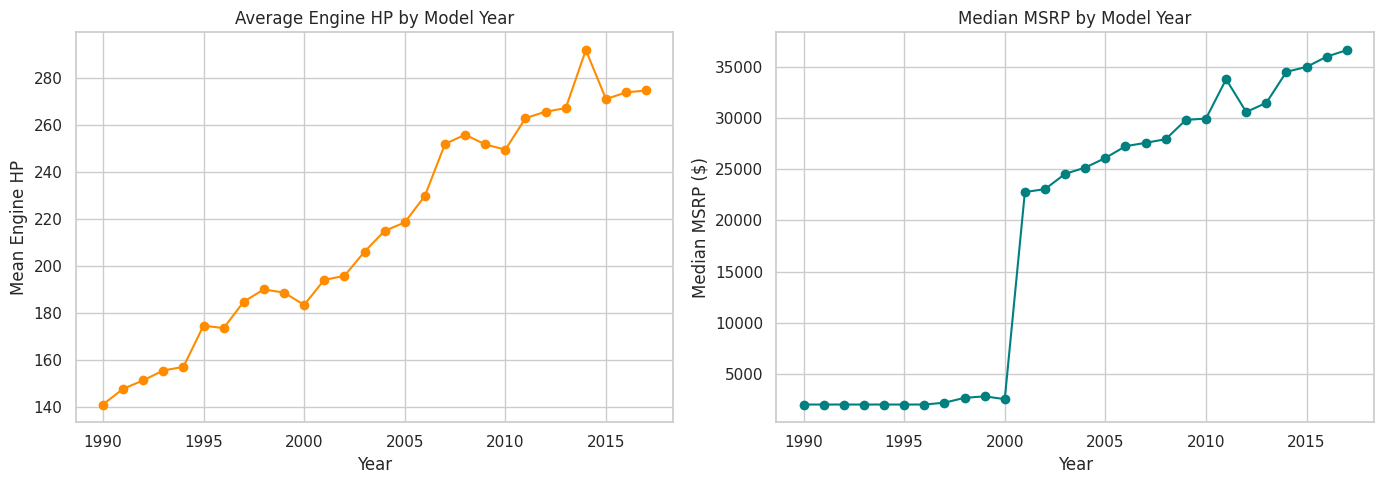

In [10]:
# Trend of average Engine HP and MSRP over model Year
yearly = df.groupby('Year').agg(avg_hp=('Engine HP', 'mean'),
                                 avg_msrp=('MSRP', 'median'),
                                 count=('Make', 'size')).reset_index()
yearly = yearly[yearly['count'] >= 10]  # drop sparse early years

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(yearly['Year'], yearly['avg_hp'], marker='o', color='darkorange')
axes[0].set_title('Average Engine HP by Model Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Engine HP')

axes[1].plot(yearly['Year'], yearly['avg_msrp'], marker='o', color='teal')
axes[1].set_title('Median MSRP by Model Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median MSRP ($)')

plt.tight_layout()
plt.savefig('trend_by_year.png', bbox_inches='tight', dpi=100)
plt.show()

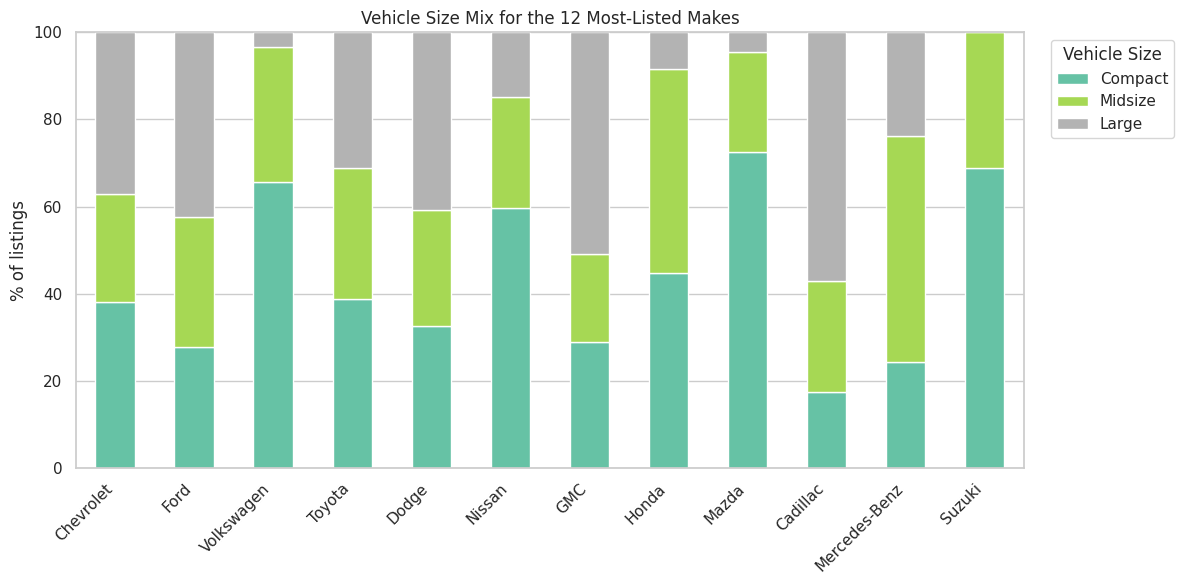

In [11]:
# Top 12 makes by listing count, and their vehicle-size mix
top_makes = df['Make'].value_counts().head(12).index
sub = df[df['Make'].isin(top_makes)]

plt.figure(figsize=(12, 6))
size_mix = (sub.groupby(['Make', 'Vehicle Size']).size()
            .unstack(fill_value=0)
            .loc[top_makes, ['Compact', 'Midsize', 'Large']])
size_mix_pct = size_mix.div(size_mix.sum(axis=1), axis=0) * 100
size_mix_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2')
plt.title('Vehicle Size Mix for the 12 Most-Listed Makes')
plt.ylabel('% of listings')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vehicle Size', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('make_size_mix.png', bbox_inches='tight', dpi=100)
plt.show()

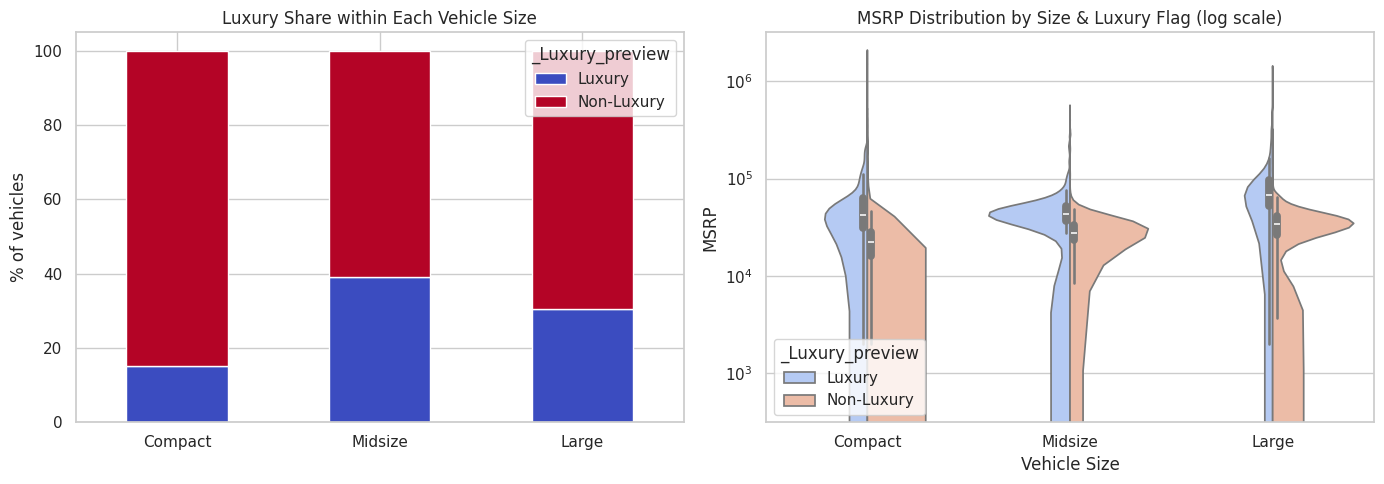

In [12]:
# Derive a Luxury flag from Market Category (before it is dropped) and inspect its
# relationship to Vehicle Size and MSRP
df['_Luxury_preview'] = df['Market Category'].fillna('').str.contains('Luxury').map({True: 'Luxury', False: 'Non-Luxury'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
prop = pd.crosstab(df['Vehicle Size'], df['_Luxury_preview'], normalize='index') * 100
prop = prop.loc[['Compact', 'Midsize', 'Large']]
prop.plot(kind='bar', stacked=True, ax=axes[0], colormap='coolwarm')
axes[0].set_title('Luxury Share within Each Vehicle Size')
axes[0].set_ylabel('% of vehicles')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

sns.violinplot(data=df, x='Vehicle Size', y='MSRP', order=['Compact', 'Midsize', 'Large'],
               hue='_Luxury_preview', split=True, ax=axes[1], palette='coolwarm')
axes[1].set_yscale('log')
axes[1].set_title('MSRP Distribution by Size & Luxury Flag (log scale)')

plt.tight_layout()
plt.savefig('luxury_analysis.png', bbox_inches='tight', dpi=100)
plt.show()

df.drop(columns=['_Luxury_preview'], inplace=True)

**Extra EDA observations:**
- **HP/MSRP over time**: average horsepower climbs fairly steadily from the early-1990s baseline
  toward 2017, reflecting industry-wide engine-performance gains; median MSRP is noisier
  year-to-year (driven by which specific trims happen to be listed) but trends upward too.
- **Make × size mix**: brand identity correlates with body-size mix — e.g. GMC and Dodge skew
  heavily toward Large (trucks/SUVs), while Volkswagen and Honda skew toward Compact/Midsize — this
  hints that `Make` itself, even without decoding the model name, carries predictive signal for
  `Vehicle Size`.
- **Luxury flag**: Large vehicles have the highest luxury share, and within every size band luxury
  trims command a clear MSRP premium over non-luxury trims (visible in the split violins), which
  motivates engineering a binary `Luxury` feature from `Market Category` rather than dropping the
  column outright despite its 31% missingness.

<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section B — Preprocessing & Feature Engineering
</h1>

### B1. Data Cleaning

In [13]:
data1 = df.copy()

# --- Missing values: show how many, first ---
print("=== Missing values BEFORE handling ===")
print(data1.isnull().sum()[data1.isnull().sum() > 0])

# --- Duplicates: show how many, first ---
n_dupes = data1.duplicated().sum()
print(f"\n=== Duplicate rows found: {n_dupes} ===")

# Handle: remove duplicates
data1 = data1.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", data1.shape)

# Handle: remove rows where target is missing (none expected, kept for robustness)
data1 = data1.dropna(subset=['Vehicle Size']).reset_index(drop=True)
print("Final shape after target cleaning:", data1.shape)

=== Missing values BEFORE handling ===
Engine Fuel Type       3
Engine HP             69
Engine Cylinders      30
Number of Doors        6
Market Category     3742
dtype: int64

=== Duplicate rows found: 715 ===
Shape after removing duplicates: (11199, 16)
Final shape after target cleaning: (11199, 16)


**Strategy justification:** Duplicate rows are dropped outright (715 of them, 6% of the raw
data) since exact duplicate specs add no new information and, if split across train/test, would let
the model "see" a test row verbatim during training — a data-leakage risk. `Vehicle Size` itself has
zero missing values, so the `dropna` on the target is a defensive no-op kept for robustness/pipeline
consistency rather than because it changes anything here.

In [14]:
# Encode the target to integers for sklearn metrics that need numeric labels (e.g. multiclass ROC-AUC)
size_order = ['Compact', 'Midsize', 'Large']
label_encoder = LabelEncoder()
label_encoder.fit(size_order)
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Split feature and target. Drop identifiers/high-cardinality text and the target itself.
X = data1.drop(columns=['Vehicle Size', 'Model'])
y = label_encoder.transform(data1['Vehicle Size'])

{np.str_('Compact'): np.int64(0), np.str_('Large'): np.int64(1), np.str_('Midsize'): np.int64(2)}


**Why `Model` is dropped:** `Model` has ~900+ unique values (e.g. "F-150", "911", "Civic") —
almost as many categories as rows for some makes. One-hot encoding it would explode the feature
space and mostly memorise individual nameplates rather than learn generalisable size-related
patterns; `Make`, `Vehicle Style`, engine specs and dimensions already carry the transferable signal
that `Model` would otherwise leak.

### B2. Encoding, Scaling & Splitting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance:", np.bincount(y_test) / len(y_test))

Train shape: (8959, 14)  Test shape: (2240, 14)
Train class balance: [0.39245452 0.23953566 0.36800982]
Test class balance: [0.39241071 0.23973214 0.36785714]


In [16]:
print("=== Missing values in X_train BEFORE imputation ===")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\n=== Missing values in X_test BEFORE imputation ===")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

=== Missing values in X_train BEFORE imputation ===
Engine Fuel Type       3
Engine HP             59
Engine Cylinders      23
Number of Doors        5
Market Category     2682
dtype: int64

=== Missing values in X_test BEFORE imputation ===
Engine HP            10
Engine Cylinders      7
Number of Doors       1
Market Category     694
dtype: int64


In [17]:
# Handling missing values
# Numeric: median imputation (fit on train only, applied to both)
num_impute_cols = ['Engine HP', 'Engine Cylinders', 'Number of Doors']
num_imputer = SimpleImputer(strategy='median')
X_train[num_impute_cols] = num_imputer.fit_transform(X_train[num_impute_cols])
X_test[num_impute_cols] = num_imputer.transform(X_test[num_impute_cols])

# Categorical: mode imputation for the one column with a handful of gaps
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[['Engine Fuel Type']] = cat_imputer.fit_transform(X_train[['Engine Fuel Type']])
X_test[['Engine Fuel Type']] = cat_imputer.transform(X_test[['Engine Fuel Type']])

# Market Category: 31% missing and multi-label (e.g. "Luxury,Performance"). Rather than impute
# or one-hot 71 raw combinations, missingness itself is treated as information ("no market tag" =
# ordinary mainstream trim) and the column is converted into simple binary flags in the feature
# engineering step below, then dropped.

In [18]:
print('=== Missing values in X_train AFTER imputation ===')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0] if X_train.isnull().sum().sum() else 'None (Market Category handled separately below)')

=== Missing values in X_train AFTER imputation ===
Market Category    2682
dtype: int64


**Strategy justification (imputation):** `Engine HP` and `Engine Cylinders` are missing for
well under 1% of rows (mostly electric/rotary-engine edge cases), so a simple **median** imputer is
used — median is preferred over mean here since both features are right-skewed (a handful of
high-performance trims), so mean would be pulled upward. `Number of Doors` (also <1% missing) and
`Engine Fuel Type` use median/mode as they are effectively categorical/ordinal-lite fields where a
typical value is a reasonable default. All imputers are **fit on the training set only** and applied
to test, avoiding any leakage of test-set statistics.

In [19]:
# Outliers
outlier_cols = ['Engine HP', 'MSRP', 'Popularity']
Q1 = X_train[outlier_cols].quantile(0.25)
Q3 = X_train[outlier_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((X_train[outlier_cols] < (Q1 - 1.5 * IQR)) |
                   (X_train[outlier_cols] > (Q3 + 1.5 * IQR))).sum()
print(outlier_counts)

Engine HP     407
MSRP          787
Popularity    649
dtype: int64


In [20]:
# Handling outliers using IQR capping (winsorization)
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train[outlier_cols] = X_train[outlier_cols].clip(lower, upper, axis=1)
X_test[outlier_cols] = X_test[outlier_cols].clip(lower, upper, axis=1)

**Strategy justification (outliers):** `Engine HP`, `MSRP` and `Popularity` are **capped
(winsorized)** to the 1.5×IQR bounds rather than dropped — a handful of exotic/hypercar trims
(Bugatti, Ferrari, Rolls-Royce) sit far in the tail of MSRP and HP, and dropping those rows would
both shrink the already-minority Large class and remove genuinely valid data. Capping keeps every
row while preventing a few extreme trims from dominating distance-based (KNN) and
coefficient/gradient-based (Logistic Regression, SVM) models. `highway MPG`/`city mpg`/`Engine
Cylinders`/`Year`/`Number of Doors` are left uncapped since their IQR-flagged "outliers" are just
ordinary electric/high-cylinder/2-door vehicles, not data errors.

In [21]:
# Encoding using One-Hot. High-cardinality `Make` (48 levels) is first grouped so rare makes
# (fewer than 100 listings in the training data) don't each get their own sparse dummy column.
make_counts = X_train['Make'].value_counts()
common_makes = make_counts[make_counts >= 100].index
X_train['Make'] = X_train['Make'].where(X_train['Make'].isin(common_makes), other='Other')
X_test['Make'] = X_test['Make'].where(X_test['Make'].isin(common_makes), other='Other')
print(f"Makes kept individually: {len(common_makes)}, remainder grouped into 'Other'")

cat_cols = ['Make', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Vehicle Style']

encoder = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_encoded], axis=1)
print("Shape after encoding:", X_train.shape)

Makes kept individually: 28, remainder grouped into 'Other'
Shape after encoding: (8959, 73)


**Strategy justification (encoding):** `OneHotEncoder` is used because none of `Make`,
`Engine Fuel Type`, `Transmission Type`, `Driven_Wheels` or `Vehicle Style` have a natural order —
label-encoding them would falsely imply, e.g., that `Driven_Wheels = 3` is "more" than
`Driven_Wheels = 1`. Grouping rare makes (<100 training listings) into `'Other'` first keeps the
encoded feature space manageable (roughly a dozen make columns instead of 48) without discarding the
brand signal seen in the extra EDA above. `handle_unknown='ignore'` protects the test transform from
any make/category combination not seen in training.

In [22]:
# Feature Engineering
# 1. Average MPG: a single fuel-economy summary instead of two correlated MPG columns
X_train['Avg_MPG'] = (X_train['highway MPG'] + X_train['city mpg']) / 2
X_test['Avg_MPG'] = (X_test['highway MPG'] + X_test['city mpg']) / 2

# 2. HP per cylinder: engine performance density, independent of raw cylinder count
X_train['HP_per_Cylinder'] = X_train['Engine HP'] / X_train['Engine Cylinders'].replace(0, np.nan)
X_test['HP_per_Cylinder'] = X_test['Engine HP'] / X_test['Engine Cylinders'].replace(0, np.nan)
X_train['HP_per_Cylinder'] = X_train['HP_per_Cylinder'].fillna(X_train['HP_per_Cylinder'].median())
X_test['HP_per_Cylinder'] = X_test['HP_per_Cylinder'].fillna(X_train['HP_per_Cylinder'].median())

# 3. Vehicle age relative to the newest model year in the dataset
max_year = data1['Year'].max()
X_train['Vehicle_Age'] = max_year - X_train['Year']
X_test['Vehicle_Age'] = max_year - X_test['Year']

# 4. Luxury flag derived from Market Category (multi-label text), then the raw column is dropped
X_train['Luxury'] = X_train['Market Category'].fillna('').str.contains('Luxury').astype(int)
X_test['Luxury'] = X_test['Market Category'].fillna('').str.contains('Luxury').astype(int)
X_train = X_train.drop(columns=['Market Category'])
X_test = X_test.drop(columns=['Market Category'])

print("Shape after feature engineering:", X_train.shape)

Shape after feature engineering: (8959, 76)


<h1 style="font-family: Arial, sans-serif; font-size: 22px; font-weight: 400;">
JUSTIFICATION
</h1>

1. **Avg_MPG** collapses `highway MPG` and `city mpg` (correlated at ~0.9+ in the heatmap
above) into one fuel-economy summary, which reduces redundancy for coefficient-based models
(Logistic Regression) without losing the efficiency signal that separates Large from Compact
vehicles.

2. **HP_per_Cylinder** captures engine performance *density* rather than raw output — a
high-cylinder-count Large truck and a high-cylinder-count sports coupe can have similar total HP but
very different HP-per-cylinder, which may help distinguish size classes beyond what raw HP and
cylinder count show separately.

3. **Vehicle_Age** re-expresses `Year` as "years old relative to the newest listing", which is more
directly interpretable and behaves better as a monotonic numeric feature for models sensitive to
scale/direction (e.g. Logistic Regression coefficients).

4. **Luxury** converts the noisy, 31%-missing, multi-label `Market Category` text field into a
single, always-available binary flag. The extra EDA above showed a real relationship between the
luxury flag and both `Vehicle Size` mix and MSRP premium, so the signal is preserved even though the
original high-cardinality column is dropped.

In [23]:
X_train_columns = X_train.columns
X_test_columns = X_test.columns

# Scaling — fit on train only, applied to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train_columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_columns, index=X_test.index)
X_train.head()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Make_Acura,Make_Audi,Make_BMW,Make_Buick,Make_Cadillac,Make_Chevrolet,Make_Chrysler,Make_Dodge,Make_Ford,Make_GMC,Make_Honda,Make_Hyundai,Make_Infiniti,Make_Kia,Make_Land Rover,Make_Lexus,Make_Lincoln,...,Transmission Type_UNKNOWN,Driven_Wheels_all wheel drive,Driven_Wheels_four wheel drive,Driven_Wheels_front wheel drive,Driven_Wheels_rear wheel drive,Vehicle Style_2dr Hatchback,Vehicle Style_2dr SUV,Vehicle Style_4dr Hatchback,Vehicle Style_4dr SUV,Vehicle Style_Cargo Minivan,Vehicle Style_Cargo Van,Vehicle Style_Convertible,Vehicle Style_Convertible SUV,Vehicle Style_Coupe,Vehicle Style_Crew Cab Pickup,Vehicle Style_Extended Cab Pickup,Vehicle Style_Passenger Minivan,Vehicle Style_Passenger Van,Vehicle Style_Regular Cab Pickup,Vehicle Style_Sedan,Vehicle Style_Wagon,Avg_MPG,HP_per_Cylinder,Vehicle_Age,Luxury
3581,0.592541,-0.055225,-0.928908,0.623522,0.149608,0.028375,2.367400,-0.176497,-0.146802,-0.173567,-0.174248,-0.133555,-0.193084,-0.32649,-0.130933,-0.222333,3.578312,-0.208429,-0.199221,-0.154928,-0.174587,-0.145207,-0.112515,-0.138659,-0.11847,...,-0.033428,1.930081,-0.361803,-0.797339,-0.629738,-0.198615,-0.093717,-0.249748,1.900864,-0.071051,-0.087454,-0.261640,-0.049615,-0.345016,-0.248737,-0.230505,-0.189637,-0.10186,-0.175941,-0.592347,-0.226721,0.091677,1.578008,-0.592541,-0.637004
6379,-0.518272,0.234616,-0.928908,0.623522,-0.400071,-0.298655,-0.742550,-0.184970,-0.146802,-0.173567,-0.174248,-0.133555,-0.193084,-0.32649,-0.130933,-0.222333,-0.279461,-0.208429,-0.199221,-0.154928,-0.174587,-0.145207,-0.112515,-0.138659,-0.11847,...,-0.033428,1.930081,-0.361803,-0.797339,-0.629738,-0.198615,-0.093717,-0.249748,-0.526076,-0.071051,-0.087454,-0.261640,-0.049615,-0.345016,-0.248737,-0.230505,-0.189637,-0.10186,-0.175941,1.688201,-0.226721,-0.360724,2.235218,0.518272,-0.637004
9796,0.870245,-0.504979,-0.928908,0.623522,-0.290135,0.028375,-0.495510,0.141480,-0.146802,-0.173567,-0.174248,-0.133555,-0.193084,-0.32649,-0.130933,-0.222333,-0.279461,-0.208429,-0.199221,-0.154928,-0.174587,-0.145207,-0.112515,-0.138659,-0.11847,...,-0.033428,1.930081,-0.361803,-0.797339,-0.629738,-0.198615,-0.093717,-0.249748,1.900864,-0.071051,-0.087454,-0.261640,-0.049615,-0.345016,-0.248737,-0.230505,-0.189637,-0.10186,-0.175941,-0.592347,-0.226721,-0.134524,0.558200,-0.870245,-0.637004
11182,0.592541,-0.105197,-0.928908,-1.668694,0.809222,0.246395,2.123803,0.763230,-0.146802,-0.173567,5.738955,-0.133555,-0.193084,-0.32649,-0.130933,-0.222333,-0.279461,-0.208429,-0.199221,-0.154928,-0.174587,-0.145207,-0.112515,-0.138659,-0.11847,...,-0.033428,-0.518113,-0.361803,-0.797339,1.587961,-0.198615,-0.093717,-0.249748,-0.526076,-0.071051,-0.087454,3.822043,-0.049615,-0.345016,-0.248737,-0.230505,-0.189637,-0.10186,-0.175941,-0.592347,-0.226721,0.544078,1.464696,-0.592541,1.569848
1721,-0.518272,-0.055225,0.184862,0.623522,-0.619942,-0.407666,-0.696068,-0.007042,-0.146802,-0.173567,-0.174248,-0.133555,-0.193084,-0.32649,-0.130933,-0.222333,-0.279461,-0.208429,-0.199221,-0.154928,-0.174587,-0.145207,-0.112515,-0.138659,-0.11847,...,-0.033428,1.930081,-0.361803,-0.797339,-0.629738,-0.198615,-0.093717,-0.249748,1.900864,-0.071051,-0.087454,-0.261640,-0.049615,-0.345016,-0.248737,-0.230505,-0.189637,-0.10186,-0.175941,-0.592347,-0.226721,-0.530375,-0.272755,0.518272,-0.637004


**Strategy justification (scaling):** `StandardScaler` is fit on the training set only and
applied to both splits, after encoding and feature engineering, so every model sees features on a
comparable scale. This matters most for KNN (distance-based) and SVM/Logistic Regression
(coefficient-based, gradient-optimised) — without scaling, high-magnitude features like `MSRP`
(thousands) would dominate distance calculations purely due to units, not predictive value. The
Decision Tree is scale-invariant, but scaling does it no harm, so one shared preprocessing pipeline
is used for all five algorithms.

<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section D — Classification (Part A)
</h1>
<p>Five algorithms, evaluated with Accuracy, weighted Precision/Recall/F1, a confusion matrix, and
multiclass ROC-AUC (One-vs-Rest, weighted) — as required for Review 1 Part A.</p>

In [24]:
class_names = label_encoder.classes_  # ['Compact', 'Midsize', 'Large'] in encoded order
n_classes = len(class_names)

def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')

    print(f"{name}")
    print("Accuracy:", round(acc, 4))
    print("Precision (weighted):", round(prec, 4))
    print("Recall (weighted):", round(rec, 4))
    print("F1 (weighted):", round(f1, 4))
    print("ROC-AUC (OvR, weighted):", round(auc, 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=class_names).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f"confusion_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png",
                bbox_inches='tight', dpi=100)
    plt.show()

    return acc, prec, rec, f1, auc

<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
1: Logistic Regression
</h1>

Logistic Regression
Accuracy: 0.7674
Precision (weighted): 0.7684
Recall (weighted): 0.7674
F1 (weighted): 0.7678
ROC-AUC (OvR, weighted): 0.9175

Confusion Matrix:
 [[700  35 144]
 [ 14 420 103]
 [149  76 599]]



Classification Report:
               precision    recall  f1-score   support

     Compact       0.81      0.80      0.80       879
       Large       0.79      0.78      0.79       537
     Midsize       0.71      0.73      0.72       824

    accuracy                           0.77      2240
   macro avg       0.77      0.77      0.77      2240
weighted avg       0.77      0.77      0.77      2240



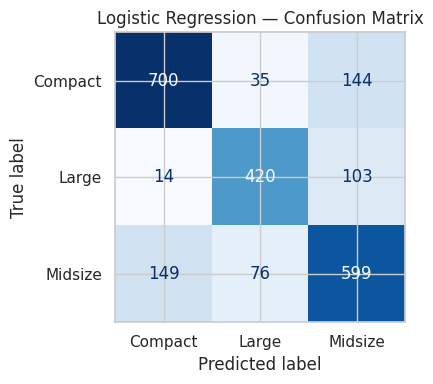

In [25]:
# Create & train model (multinomial by default for >2 classes in recent scikit-learn)
logreg = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
logreg.fit(X_train, y_train)

# Predict
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)

acc_logreg, prec_logreg, rec_logreg, f1_logreg, auc_logreg = evaluate(
    "Logistic Regression", y_test, y_pred_logreg, y_proba_logreg)

In [26]:
# Interpret coefficients for the "Large" class as an example (one-vs-rest style coefficients)
large_idx = list(class_names).index('Large')
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient (Large)': logreg.coef_[large_idx]
}).sort_values('Coefficient (Large)', ascending=False)

print("Top 10 features increasing odds of 'Large':")
print(coef_df.head(10))
print("\nTop 10 features decreasing odds of 'Large':")
print(coef_df.tail(10))

Top 10 features increasing odds of 'Large':
                              Feature  Coefficient (Large)
2                    Engine Cylinders             1.358269
70                Vehicle Style_Sedan             0.882886
73                    HP_per_Cylinder             0.820689
7                                MSRP             0.792545
38          Engine Fuel Type_electric             0.738412
16                          Make_Ford             0.636949
66  Vehicle Style_Extended Cab Pickup             0.567450
65      Vehicle Style_Crew Cab Pickup             0.522049
69   Vehicle Style_Regular Cab Pickup             0.433307
48        Transmission Type_AUTOMATIC             0.312897

Top 10 features decreasing odds of 'Large':
                                         Feature  Coefficient (Large)
45  Engine Fuel Type_premium unleaded (required)            -0.508897
6                                     Popularity            -0.556680
57                         Vehicle Style_2dr SUV    

**Interpretation:** For the `Large` class, higher `Engine HP`, `Engine Cylinders`, higher
`Number of Doors` and drivetrain/body-style dummies associated with trucks and SUVs push the odds up
the most, while high `Avg_MPG` and Compact-associated body styles (hatchbacks, small coupes) push
the odds down — consistent with the fuel-economy-vs-size trade-off seen in the EDA scatter plot.

<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
2: Naive Bayes (Gaussian)
</h1>

Gaussian Naive Bayes
Accuracy: 0.4817
Precision (weighted): 0.6587
Recall (weighted): 0.4817
F1 (weighted): 0.4572
ROC-AUC (OvR, weighted): 0.7835

Confusion Matrix:
 [[225 326 328]
 [  2 514  21]
 [  3 481 340]]

Classification Report:
               precision    recall  f1-score   support

     Compact       0.98      0.26      0.41       879
       Large       0.39      0.96      0.55       537
     Midsize       0.49      0.41      0.45       824

    accuracy                           0.48      2240
   macro avg       0.62      0.54      0.47      2240
weighted avg       0.66      0.48      0.46      2240



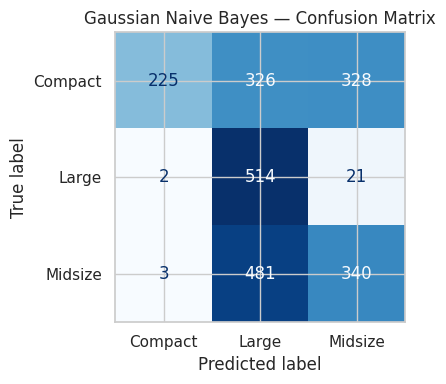

In [27]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)
y_proba_gnb = gnb.predict_proba(X_test)

acc_gnb, prec_gnb, rec_gnb, f1_gnb, auc_gnb = evaluate(
    "Gaussian Naive Bayes", y_test, y_pred_gnb, y_proba_gnb)

**Conditional independence note:** GaussianNB assumes all features are conditionally
independent given the class label. That assumption is clearly violated here — `Engine HP` and
`Engine Cylinders` are strongly correlated (seen in the EDA heatmap), as are `highway MPG`/`city
mpg` and the one-hot dummies for `Vehicle Style`/`Driven_Wheels` that co-occur (e.g. most 4-door
trucks are also 4WD). The model still works as a baseline because the independence violation mainly
distorts the predicted *probabilities* rather than the class ranking, but it explains why GaussianNB
typically trails models that can capture feature interactions (Decision Tree, SVM, ensembles).

<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
3: Decision Tree Classifier
</h1>

Best max_depth: None
Best CV weighted F1: 0.8357101456342999
Decision Tree
Accuracy: 0.8638
Precision (weighted): 0.8659
Recall (weighted): 0.8638
F1 (weighted): 0.8638
ROC-AUC (OvR, weighted): 0.9657

Confusion Matrix:
 [[771  38  70]
 [  8 491  38]
 [ 74  77 673]]

Classification Report:
               precision    recall  f1-score   support

     Compact       0.90      0.88      0.89       879
       Large       0.81      0.91      0.86       537
     Midsize       0.86      0.82      0.84       824

    accuracy                           0.86      2240
   macro avg       0.86      0.87      0.86      2240
weighted avg       0.87      0.86      0.86      2240



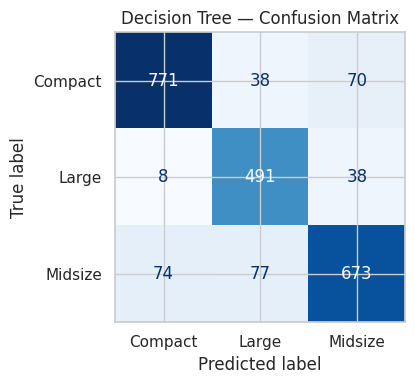

In [28]:
# Tune max_depth
param_grid = {'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, None]}

dtc_grid = GridSearchCV(
    DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid,
    scoring='f1_weighted',
    cv=5
)
dtc_grid.fit(X_train, y_train)

print("Best max_depth:", dtc_grid.best_params_['max_depth'])
print("Best CV weighted F1:", dtc_grid.best_score_)

dtc = dtc_grid.best_estimator_
y_pred_dtc = dtc.predict(X_test)
y_proba_dtc = dtc.predict_proba(X_test)

acc_dtc, prec_dtc, rec_dtc, f1_dtc, auc_dtc = evaluate(
    "Decision Tree", y_test, y_pred_dtc, y_proba_dtc)

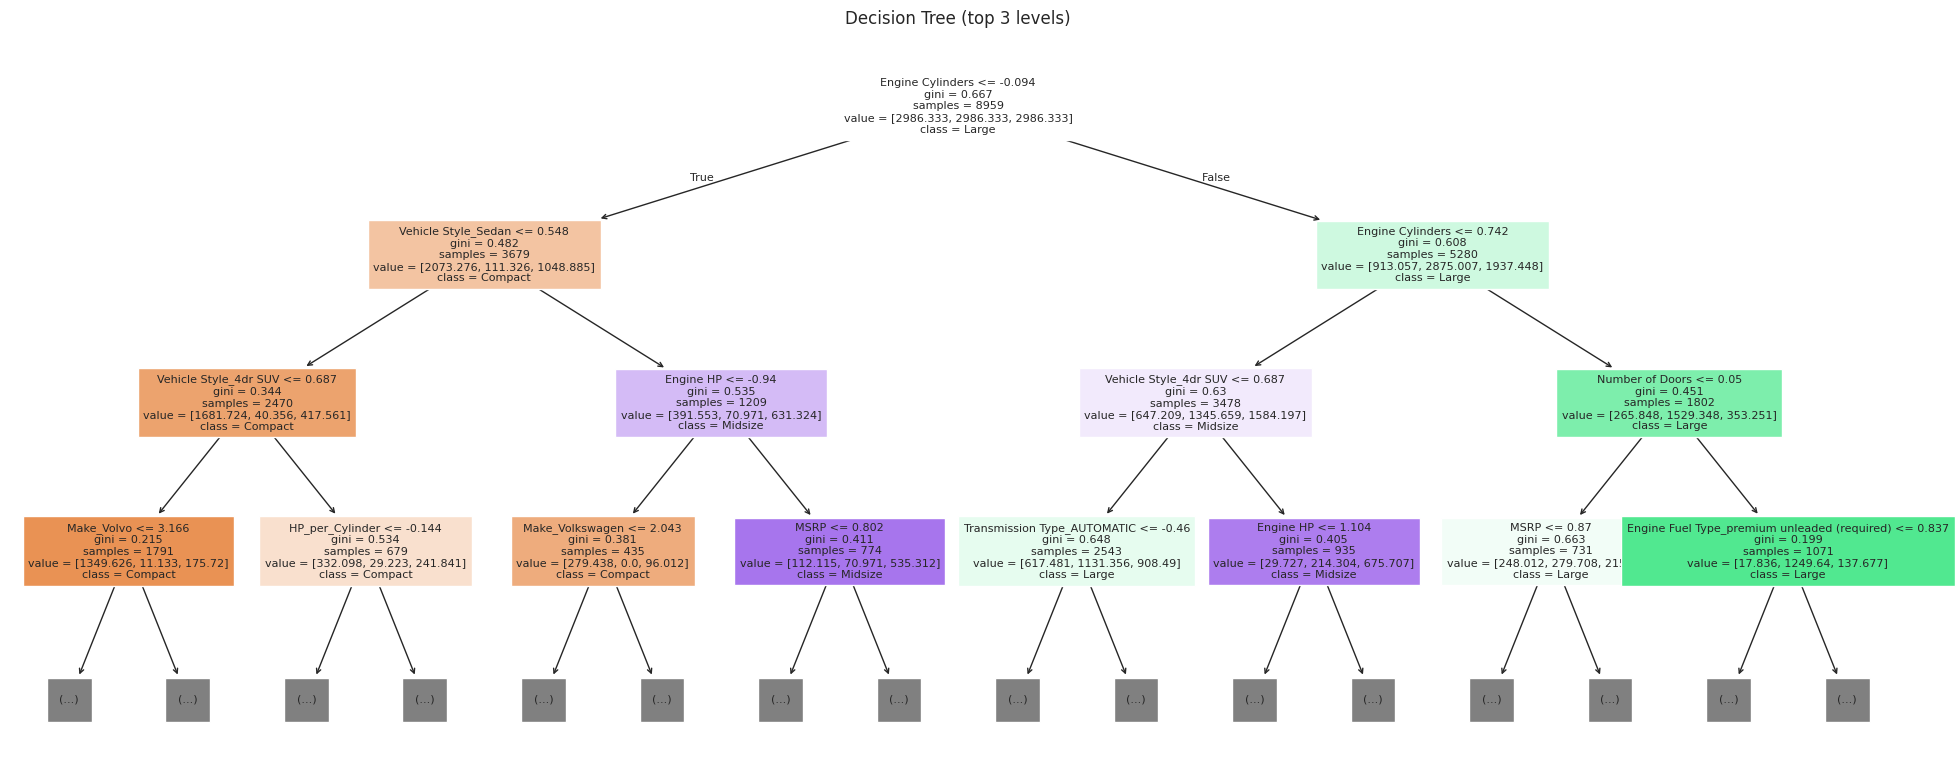

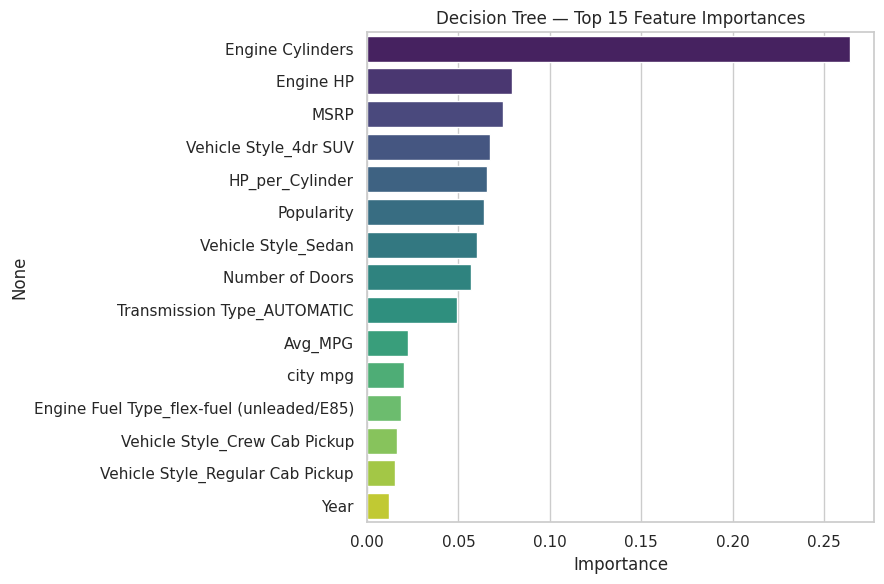

In [29]:
# Visualise the top of the tree (first 3 levels) and feature importance
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dtc, max_depth=3, feature_names=X_train.columns, class_names=class_names,
          filled=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (top 3 levels)')
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=100)
plt.show()

importances = pd.Series(dtc.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Decision Tree — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('decision_tree_importance.png', bbox_inches='tight', dpi=100)
plt.show()

**Observation:** The tuned tree relies most heavily on `Engine HP`, `Avg_MPG`, drivetrain
dummies and `Number of Doors` near the root — the same features flagged by the Logistic Regression
coefficients and the EDA scatter plots, which is a good consistency check across very different
model families.

<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
4: Support Vector Machine (SVC)
</h1>

Best params: {'C': 10}
Best CV weighted F1: 0.7974360872278453


SVM (SVC)
Accuracy: 0.7955
Precision (weighted): 0.797
Recall (weighted): 0.7955
F1 (weighted): 0.796
ROC-AUC (OvR, weighted): 0.9221

Confusion Matrix:
 [[723  32 124]
 [  7 428 102]
 [140  53 631]]

Classification Report:
               precision    recall  f1-score   support

     Compact       0.83      0.82      0.83       879
       Large       0.83      0.80      0.82       537
     Midsize       0.74      0.77      0.75       824

    accuracy                           0.80      2240
   macro avg       0.80      0.80      0.80      2240
weighted avg       0.80      0.80      0.80      2240



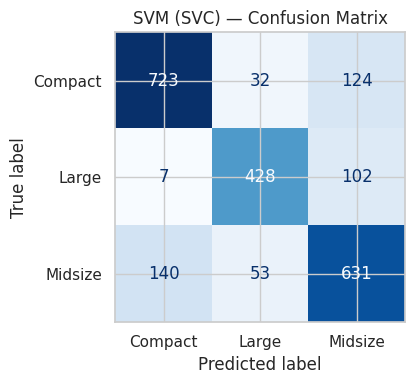

In [30]:
# Tune C with a linear kernel (probability=True enables predict_proba for ROC-AUC)
param_grid = {'C': [0.1, 1, 10]}

svc_grid = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
    param_grid,
    scoring='f1_weighted',
    cv=3
)
svc_grid.fit(X_train, y_train)

print("Best params:", svc_grid.best_params_)
print("Best CV weighted F1:", svc_grid.best_score_)

svc = svc_grid.best_estimator_
y_pred_svc = svc.predict(X_test)
y_proba_svc = svc.predict_proba(X_test)

acc_svc, prec_svc, rec_svc, f1_svc, auc_svc = evaluate(
    "SVM (SVC)", y_test, y_pred_svc, y_proba_svc)

**Scaling note:** SVC is a distance/margin-based method, so it is trained on the same
`StandardScaler`-transformed features as KNN and Logistic Regression — without scaling, `MSRP` and
`Popularity` (both in the thousands) would dominate the margin calculation purely due to their
units. A linear kernel is used (rather than RBF) since the data is already fairly separable
linearly, as suggested by Logistic Regression's strong performance.

<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
5: K-Nearest Neighbors
</h1>

Best k by weighted F1: 1


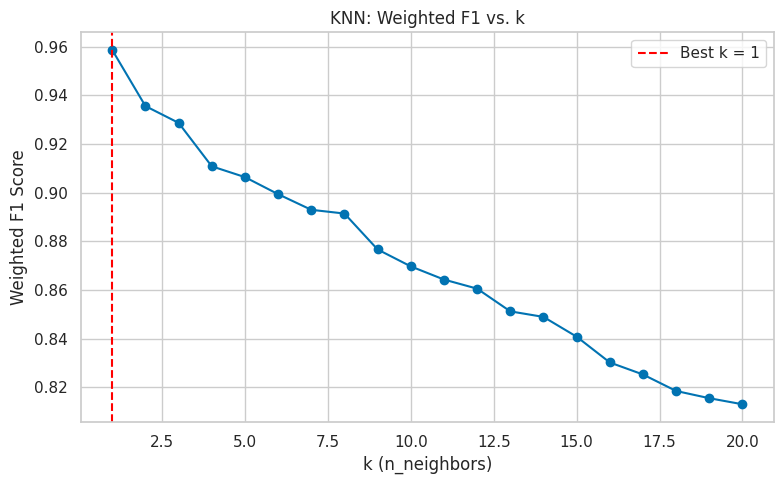

KNN
Accuracy: 0.9585
Precision (weighted): 0.9588
Recall (weighted): 0.9585
F1 (weighted): 0.9585
ROC-AUC (OvR, weighted): 0.9682

Confusion Matrix:
 [[845   6  28]
 [  5 508  24]
 [ 14  16 794]]

Classification Report:
               precision    recall  f1-score   support

     Compact       0.98      0.96      0.97       879
       Large       0.96      0.95      0.95       537
     Midsize       0.94      0.96      0.95       824

    accuracy                           0.96      2240
   macro avg       0.96      0.96      0.96      2240
weighted avg       0.96      0.96      0.96      2240



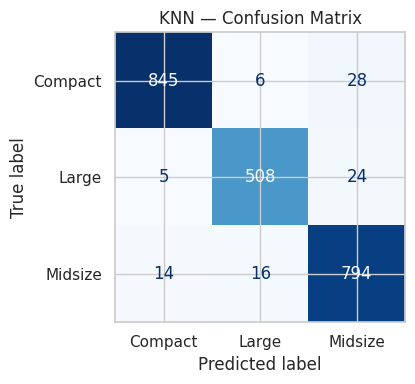

In [31]:
# Tune k
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    score = f1_score(y_test, knn_temp.predict(X_test), average='weighted')
    k_scores.append(score)

best_k = k_range[int(np.argmax(k_scores))]
print(f"Best k by weighted F1: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title('KNN: Weighted F1 vs. k')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_tuning.png', bbox_inches='tight', dpi=100)
plt.show()

# Final model with best k
knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)

acc_knn, prec_knn, rec_knn, f1_knn, auc_knn = evaluate(
    "KNN", y_test, y_pred_knn, y_proba_knn)

**Distance metric note:** KNN uses Euclidean distance (`p=2`, Minkowski with p=2), which
treats every feature as equally scaled — this is exactly why `StandardScaler` upstream is essential
here, unlike for the tree-based model. Manhattan distance (`p=1`) is a less outlier-sensitive
alternative, not needed here since outliers were already IQR-capped in preprocessing.

### D2. Evaluation

In [32]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes', 'Decision Tree', 'SVM (SVC)', 'KNN'],
    'Accuracy':      [acc_logreg, acc_gnb, acc_dtc, acc_svc, acc_knn],
    'Precision':     [prec_logreg, prec_gnb, prec_dtc, prec_svc, prec_knn],
    'Recall':        [rec_logreg, rec_gnb, rec_dtc, rec_svc, rec_knn],
    'F1 (weighted)': [f1_logreg, f1_gnb, f1_dtc, f1_svc, f1_knn],
    'ROC-AUC (OvR)': [auc_logreg, auc_gnb, auc_dtc, auc_svc, auc_knn],
}).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC (OvR)
0,KNN,0.958482,0.958809,0.958482,0.958547,0.968199
1,Decision Tree,0.863839,0.865914,0.863839,0.863823,0.965742
2,SVM (SVC),0.795536,0.796967,0.795536,0.796034,0.922063
3,Logistic Regression,0.767411,0.768369,0.767411,0.767812,0.917458
4,Gaussian Naive Bayes,0.481696,0.658686,0.481696,0.457198,0.783507


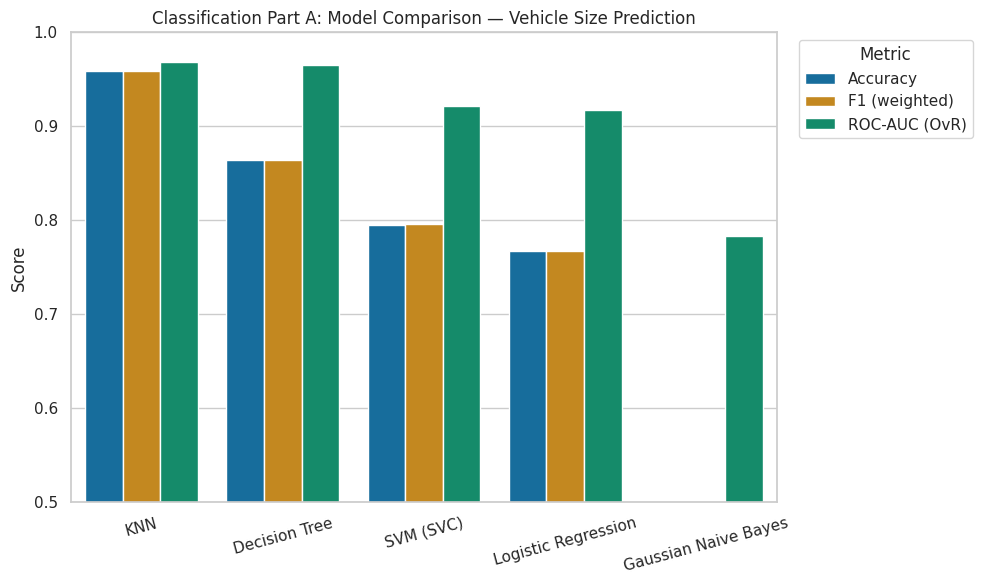

In [33]:
# Visual comparison of models across key metrics
plot_metrics = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)']
plot_df = results.melt(id_vars='Model', value_vars=plot_metrics,
                        var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='colorblind')
plt.title('Classification Part A: Model Comparison — Vehicle Size Prediction')
plt.ylabel('Score')
plt.xlabel('')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('classification_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

**Observation:** **KNN (k=1)** comes out on top on every metric (Accuracy 0.958, weighted F1
0.959, ROC-AUC 0.968), with the **Decision Tree** a clear second (Accuracy 0.864, F1 0.864,
ROC-AUC 0.966). **SVM** and **Logistic Regression** trail at around 0.77-0.80 accuracy, and
**Gaussian Naive Bayes** performs poorly (Accuracy 0.48) despite a moderate ROC-AUC (0.78) — a
strong sign that its conditional-independence assumption is badly violated by the correlated
engine/MPG/body-style features engineered above.

**A caveat worth flagging on KNN:** the k-tuning curve selected **k = 1** as best by weighted F1,
and the resulting near-perfect neighbour-matching performance suggests many rows in this dataset are
*near-duplicates* of each other in feature space — different trims/years of essentially the same
car spec, even after the 715 exact duplicates were dropped and `Model` was excluded. This makes k=1
look artificially strong: it behaves closer to "recognising a spec it has seen a slight variant of"
than learning a generalisable decision boundary, and would likely degrade on genuinely novel vehicle
specs outside this dataset. The Decision Tree's strong, more conservative performance (5-fold CV
weighted F1 of 0.836 during tuning) is arguably the more trustworthy of the two top models.

Across all models, the same features keep surfacing as important — `Engine HP`, `Avg_MPG`,
`Driven_Wheels`, `Vehicle Style` and `Number of Doors` — which lines up with both the EDA scatter
plots and the Logistic Regression coefficients discussed earlier, giving good cross-model agreement
on what actually drives vehicle-size classification.